**Machine Learning and Data Mining**
> **Professor: Sthefanie Passo**

> **Conference Link: https://www.american-cse.org/csci2025/RTAI**

# Keras 3.5.0

Keras is a high-level, open-source deep learning API built on top of libraries such as TensorFlow. It is designed to simplify the process of building and training deep learning models, making it accessible to beginners and efficient for researchers and developers.


In [1]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
keras.version()

'3.8.0'

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print("X_train.shape \n", X_train.shape)
print("y_train.shape \n", y_train.shape)
print("X_test.shape \n", X_test.shape)
print("y_test.shape \n", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train.shape 
 (60000, 28, 28)
y_train.shape 
 (60000,)
X_test.shape 
 (10000, 28, 28)
y_test.shape 
 (10000,)


In [ ]:
print(X_train.dtype)
print(X_train[0])
print(y_train[0])

uint8
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 

In [ ]:
197/255

0.7725490196078432

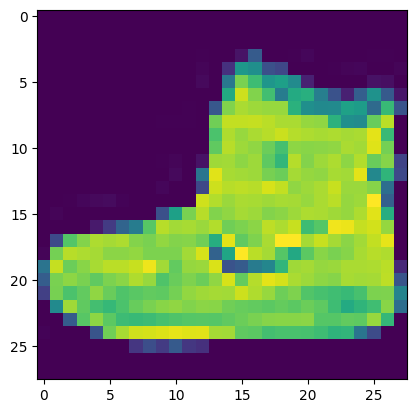

In [ ]:
X_train[0].shape
plt.imshow(X_train[0])

In [ ]:
X_valid, X_train = X_train[0:5000]/255.0, X_train[5000:]/255.0    #normalize the data to be between 0 and 1.
y_valid, y_train = y_train[0:5000], y_train[5000:]

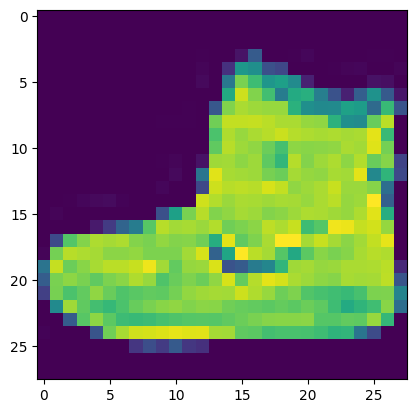

In [ ]:
plt.imshow(X_valid[0])

We can also process the labels afterwards with one-hot-encoding:

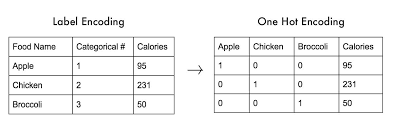

In [ ]:
lables = ['tshirt-top', 'trowser', 'pullover', 'dress', 'coat', 'sandle', 'shirt', 'sneaker', 'bag', 'ankle-boot']

## API Sequential

In [ ]:
model1 = keras.models.Sequential()
model1.add(keras.layers.Input(shape=[28,28], name = 'input'))
model1.add(keras.layers.Flatten())
model1.add(keras.layers.Dense(300, activation='relu', name='hidden_1')) # here 300 is number of neurons,
model1.add(keras.layers.Dense(100, activation='relu', name='hidden_2'))
model1.add(keras.layers.Dense(10, activation='softmax', name='output')) #adam, relu, alu

In [ ]:
model2 = keras.models.Sequential(
    [
        keras.layers.Input(shape=[28,28], name = 'input'),
        keras.layers.Flatten(),
        keras.layers.Dense(300, activation='relu', name='hidden_1'),
        keras.layers.Dense(100, activation='relu', name='hidden_2'),
        keras.layers.Dense(10, activation='softmax', name='output')
    ]
)

In [ ]:
model3 = keras.models.Sequential(
    [
        keras.layers.Flatten(input_shape=[28,28]),
        keras.layers.Dense(300, activation='relu', name='hidden_1'),
        keras.layers.Dense(100, activation='relu', name='hidden_2'),
        keras.layers.Dense(10, activation='softmax', name='output')
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_1 (Dense)                     │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.layers

[<Flatten name=flatten, built=True>,
 <Dense name=hidden_1, built=True>,
 <Dense name=hidden_2, built=True>,
 <Dense name=output, built=True>]

In [ ]:
model3.layers[1].name


'hidden_1'

In [ ]:
model3.layers[3].name

'output'

#Homework
Research what are flatten and dense layers of Sequential model and how do they work.
Include images of flatten and dense layers with a description explaining each of them.

![link text](https://www.corpnce.com/wp-content/uploads/2023/12/fnn.jpeg)

# Sequential Model
The **Sequential model** in Keras is the most common way to build a feedforward neural network (FNN).

Key Properties:
* Layers are added sequentially (one after another).
* Each layer has one input and one output (no branching).
* Best for simple models like CNNs, FNNs, and LSTMs.

# Flatten Layer
* The **Flatten layer** reshapes multi-dimensional inputs (e.g., 2D image matrices) into a 1D vector (without affecting batch size).
For example, if input shape = (batch_size, 28, 28), then after Flatten(), the shape becomes (batch_size, 784).
* It is commonly used before Dense layers in CNNs and image-based models.
* Required before using Fully Connected (Dense) layers.

# Dense Layer
A **Dense layer** (fully connected layer) is a basic neural network layer where:
* Each neuron is connected to every neuron in the next layer.
* It adds trainable weights (W) and biases (b) to learn patterns, and performs the weighted sum of inputs followed by an activation function.

* Z=W⋅X+b
* A=f(Z) where f is an activation function

* Helps convert features into meaningful representations.


In [ ]:
model3.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"] )

In [ ]:
history = model3.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7849 - loss: 0.6060 - val_accuracy: 0.8698 - val_loss: 0.3630
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8647 - loss: 0.3650 - val_accuracy: 0.8738 - val_loss: 0.3555
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8777 - loss: 0.3308 - val_accuracy: 0.8820 - val_loss: 0.3313
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8877 - loss: 0.3047 - val_accuracy: 0.8868 - val_loss: 0.3202
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8941 - loss: 0.2837 - val_accuracy: 0.8878 - val_loss: 0.3263
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8994 - loss: 0.2679 - val_accuracy: 0.8866 - val_loss: 0.3174
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9055 - loss: 0.2544 - val_accuracy: 0.8838 - val_loss: 0.3239
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9088 - loss: 0.2408 

<Axes: >

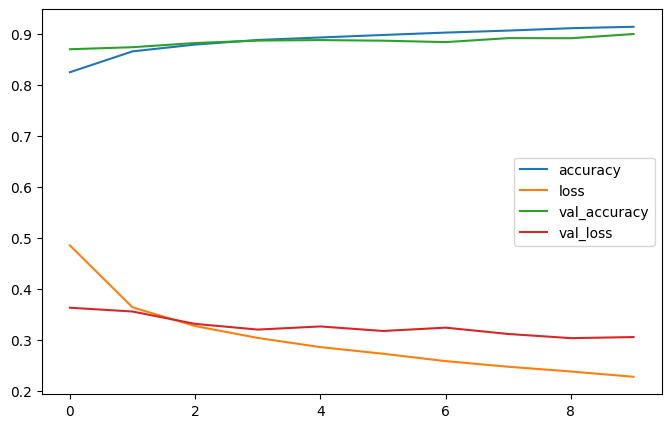

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8,5))

Homework 2: create a model with the numbers dataset with the model3 doing the necessary adaptations, print the histogram at the end. Compare the model3 result with the model that you where using.

To save the model in the drive we can use:

In [ ]:
model3.save("model3-fashion-mnist.h5") #hierarchical data format

In [ ]:
model_clone = keras.models.load_model("model3-fashion-mnist.h5")

In [ ]:
y_hat = model_clone.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print("y_hat[0]", y_hat[0])
print("y_test[0]", y_test[0] #?)


y_hat[0] [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
y_test[0] 9


In [ ]:
model_clone.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8789 - loss: 54.9495


[54.616268157958984, 0.8776000142097473]

In [ ]:
#model_clone.evaluate()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

# Functional API

In [ ]:
#from typing_extensions import Concatenate   #??????

input = keras.layers.Input(shape=[28,28])
h0 = keras.layers.Flatten()(input)
h1 = keras.layers.Dense(300, activation="relu")(h0)
h2 = keras.layers.Dense(200, activation="relu")(h1)
h3 = keras.layers.Dense(100, activation="relu")(h2)
h4 = keras.layers.Dense(50, activation="relu")(h3)
concat = keras.layers.Concatenate()([h1,h4])
output = keras.layers.Dense(10, activation="softmax")(concat)
model_api = keras.models.Model(inputs=[input], outputs=[output]) # Functional API provides support for multiple inputs and multiple outputs

In [ ]:
#model_api.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy", "loss"])
model_api.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
history_api = model_api.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 28, 28))
  warnings.warn(msg)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9295 - loss: 0.1855 - val_accuracy: 0.9052 - val_loss: 0.2789
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9354 - loss: 0.1722 - val_accuracy: 0.9054 - val_loss: 0.2764
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9391 - loss: 0.1619 - val_accuracy: 0.9056 - val_loss: 0.2765
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9398 - loss: 0.1593 - val_accuracy: 0.9068 - val_loss: 0.2773
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9392 - loss: 0.1609 - val_accuracy: 0.9056 - val_loss: 0.2811
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9413 - loss: 0.1556 - val_accuracy: 0.9066 - val_loss: 0.2816
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9407 - loss: 0.1566 - val_accuracy: 0.9062 - val_loss: 0.2827
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9413 - loss: 0.1571 - val_accurac

* Homework: train the model, plot the history of the training, save the model, evaluate the model with the test data.

<Axes: >

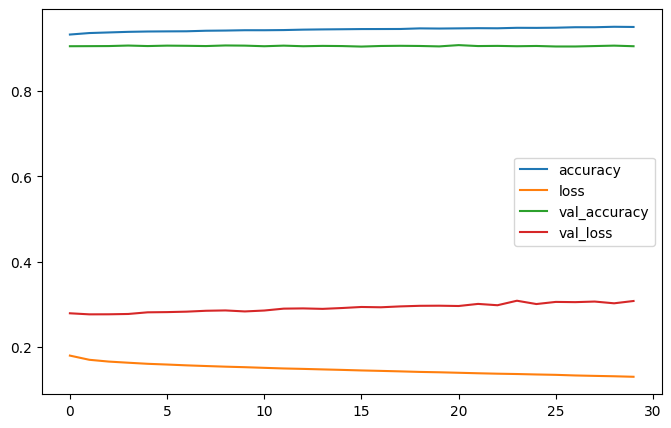

In [ ]:
pd.DataFrame(history_api.history).plot(figsize=(8,5))

# New Section

In [ ]:
model_api.save("model_api-fashion-mnist.h5") #hierarchical data format

In [ ]:
model_api_clone = keras.models.load_model("model_api-fashion-mnist.h5")

In [ ]:
y_hat_api = model_api_clone.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print("y_hat_api[0]", y_hat_api[0])
print("y_test[0]", y_test[0])

y_hat_api[0] [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
y_test[0] 9


In [ ]:
model_api_clone.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8708 - loss: 65.0395


[67.63265228271484, 0.8687000274658203]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.99999994],
       [0.        , 0.        , 0.99999994, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.99999994,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

# An autoencoder

An autoencoder is a type of neural network designed to compress input data into a lower-dimensional latent space (encoder) and then reconstruct it back to its original form (decoder), minimizing reconstruction error.

In [ ]:
X_train_flat = X_train.reshape(-1, 784) #flattening two dimensional images into one dimension, required by Keras for input; -1 is a placeholder for number of records, and each 28x28 image is flattened to 784 one dimensional vector
X_valid_flat = X_valid.reshape(-1, 784)

X_test_flat = X_test.reshape(-1, 784)

In [ ]:
print("X_train_flat.shape:", X_train_flat.shape)
print("X_train.shape:", X_train.shape)

X_train_flat.shape: (55000, 784)
X_train.shape: (55000, 28, 28)


In [ ]:
input = keras.layers.Input(shape=(784,))    #tuple shape with one element requires trailing comma. Tuple shape for input is required for Keras layers
h1 = keras.layers.Dense(64, activation="relu")(input) #chaining/connecting input to h1, to pass input data to h1
h2 = keras.layers.Dense(32, activation="relu")(h1) # connecting h1 to h2, to pass output of h1 to h2. Here h2 is the lowest dimension latent space, compressed from 784 to 32
h3 = keras.layers.Dense(64, activation="relu")(h2) # Start reconstructing back to higher dimension
output = keras.layers.Dense(784, activation="relu")(h3) # reconstructed back to the original shape 784
model_photoshop = keras.models.Model(inputs=[input], outputs=[output])
model_photoshop.compile(loss="binary_crossentropy", optimizer = "adam")

In [ ]:
history_encoder = model_photoshop.fit(X_train_flat, X_train_flat, epochs=10, validation_data=(X_valid_flat, X_valid_flat))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 784))
  warnings.warn(msg)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.9722 - val_loss: 0.7236
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7049 - val_loss: 0.6784
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6284 - val_loss: 0.5918
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5963 - val_loss: 0.5800
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.5825 - val_loss: 0.5699
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.5679 - val_loss: 0.5729
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5886 - val_loss: 0.5601
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5483 - val_loss: 0.5342
Epoch 9/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5266 - val_loss: 0.5101
Epoch 10/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5145 - val_loss: 0.5114


<Axes: >

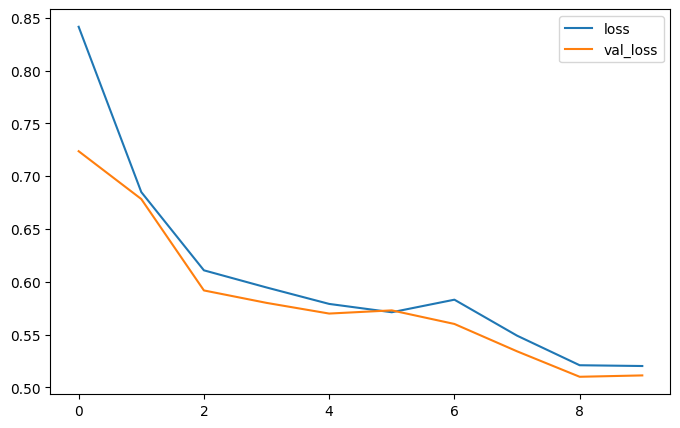

In [ ]:
#plot the history,save the model, request it back and evaluate it
pd.DataFrame(history_encoder.history).plot(figsize=(8,5))

In [ ]:
def show_results(model, X_test, limit=10):
  x_prediction = model.predict(X_test)

  plt.figure(figsize=(20,4))
  for i in range(0,limit):
    sub_plot = plt.subplot(2,10,i+1)
    plt.imshow(X_test[i].reshape(28,28))
    plt.gray()
    sub_plot.get_xaxis().set_visible(True)
    sub_plot.get_yaxis().set_visible(True)


    sub_plot = plt.subplot(2,10,i+11)
    plt.imshow(x_prediction[i].reshape(28,28))
    plt.gray()
    sub_plot.get_xaxis().set_visible(False)
    sub_plot.get_yaxis().set_visible(False)

  plt.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


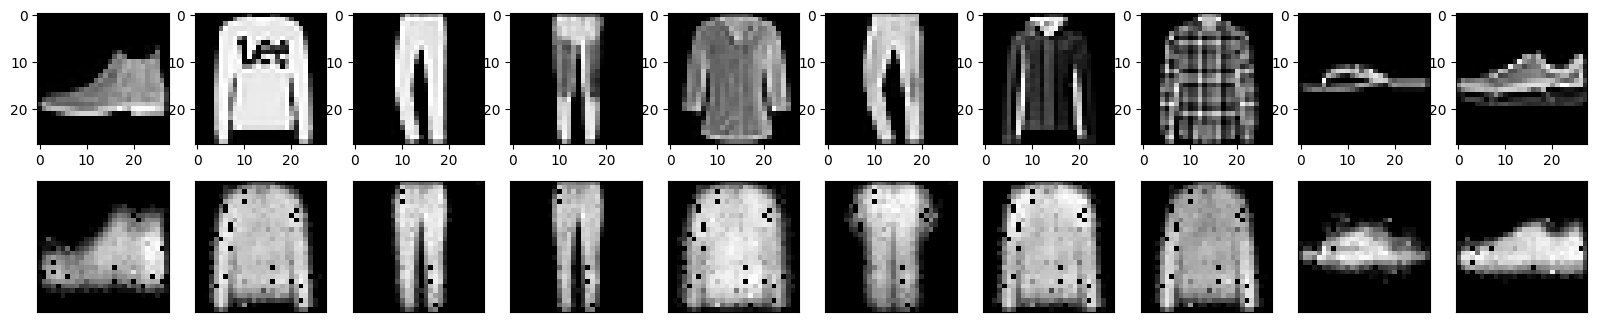

In [ ]:
show_results(model_photoshop, X_test_flat)

# Keras 3.5.0, API Subclassing

In [ ]:
class WideAndDeepModel(keras.models.Model):
  def __init__(self, activation="relu", **kwargs):
    super(WideandDeepModel,self).__init__(**kwargs)
    self.h0 = keras.layers.Flatten()
    self.h1 = keras.layers.Dense(300, activation=activation)
    self.h2 = keras.layers.Dense(200, activation=activation)
    self.h3 = keras.layers.Dense(100, activation=activation)
    self.h4 = keras.layers.Dense(50, activation=activation)
    self.h5 = keras.layers.Dense(10, activation="softmax")

  def call(self, inputs):
    'NN forward, chain, input and concatenate. return the NN'
    #challenge: complete this code


In [ ]:
model = WideAndDeepModel()

In [ ]:
#data: X_train, y_train...

In [ ]:
# do the model fit, plot the history, save the model, evaluate the model

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6883 - loss: 0.9900 - val_accuracy: 0.8342 - val_loss: 0.5176
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8254 - loss: 0.5142 - val_accuracy: 0.8510 - val_loss: 0.4469
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8412 - loss: 0.4525 - val_accuracy: 0.8604 - val_loss: 0.4143
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8489 - loss: 0.4285 - val_accuracy: 0.8592 - val_loss: 0.4100
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8568 - loss: 0.4040 - val_accuracy: 0.8550 - val_loss: 0.4024
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8667 - loss: 0.3802 - val_accuracy: 0.8706 - val_loss: 0.3781
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8708 - loss: 0.3698 - val_accuracy: 0.8750 - val_loss: 0.3657
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8735 - loss: 0.3575

Model: "wide_and_deep_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 200)                 │          60,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 100)                 │          20,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 10)                  │           3,510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 324,362 (1.24 MB)

 Trainable params: 324,360 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)